In [36]:
!pip install matplotlib
!pip install seaborn

In [18]:
!pip install scikit-learn

  Using cached scikit_learn-1.7.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (17 kB)
  Using cached scipy-1.15.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached joblib-1.5.1-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.7.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.9 MB)
Using cached joblib-1.5.1-py3-none-any.whl (307 kB)
Using cached scipy-1.15.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (37.7 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]


In [3]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

with open('data_clean.pkl', 'rb') as f:
    saved = pickle.load(f)
    price_df = saved['price_df']
    return_df = saved['return_df']
    category_map = saved['category_mapping']

In [8]:
from itertools import chain

flat_categories = set(chain.from_iterable(category_map.values()))
print(flat_categories)

{'trend', 'em_equity', 'inflation', 'interest_rate', 'bitcoin', 'commodities', 'small_cap', 'equity', 'us_dollar', 'us_equity', 'value', 'momentum', 'quality', 'credit', 'long_vol', 'low_vol'}


In [9]:
for ticker, category in category_map.items():
    print(f"{ticker}: {category}")

core_macro: ['commodities', 'credit', 'interest_rate', 'equity']
secondary_macro: ['us_dollar', 'us_equity', 'inflation', 'bitcoin', 'em_equity']
macro_styles: ['trend', 'long_vol']
equity_styles: ['value', 'small_cap', 'low_vol', 'momentum', 'quality']



### US_DOLLAR ###


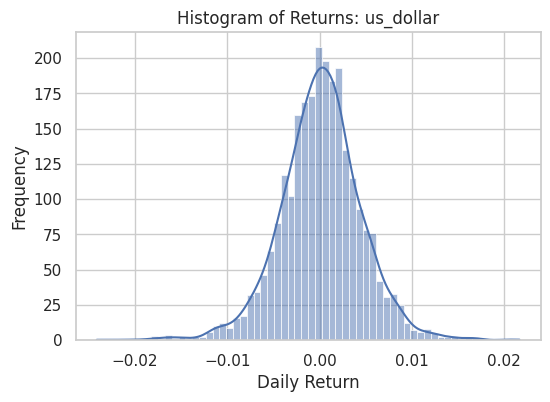

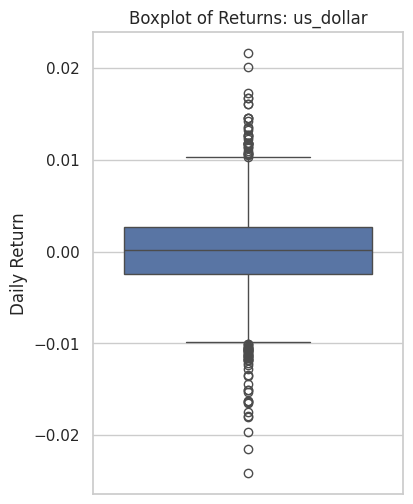

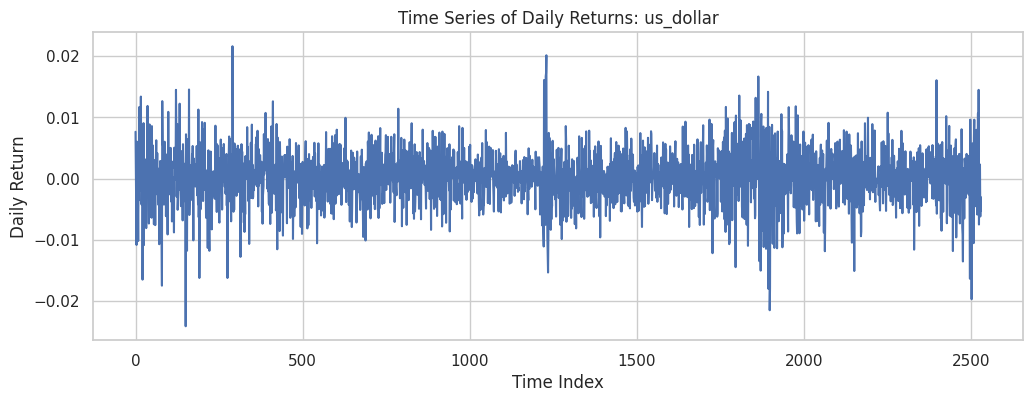

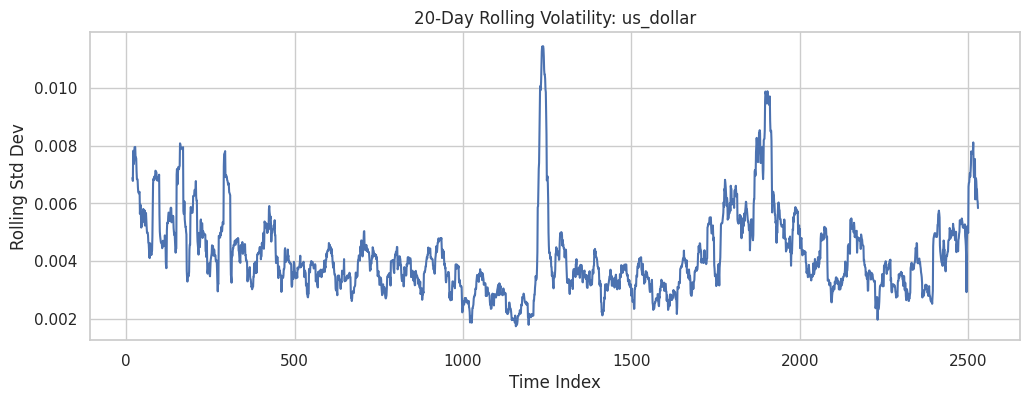


### US_EQUITY ###


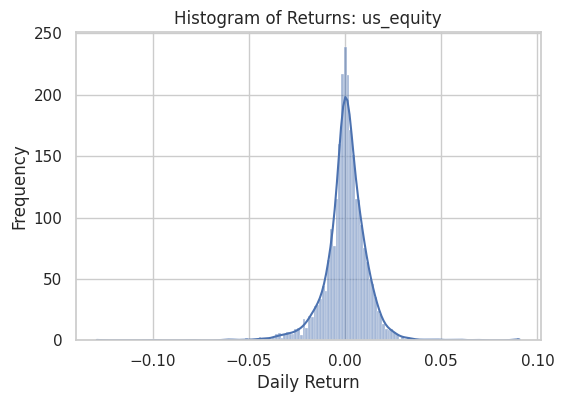

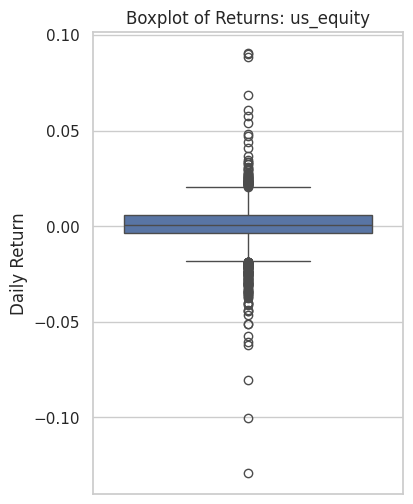

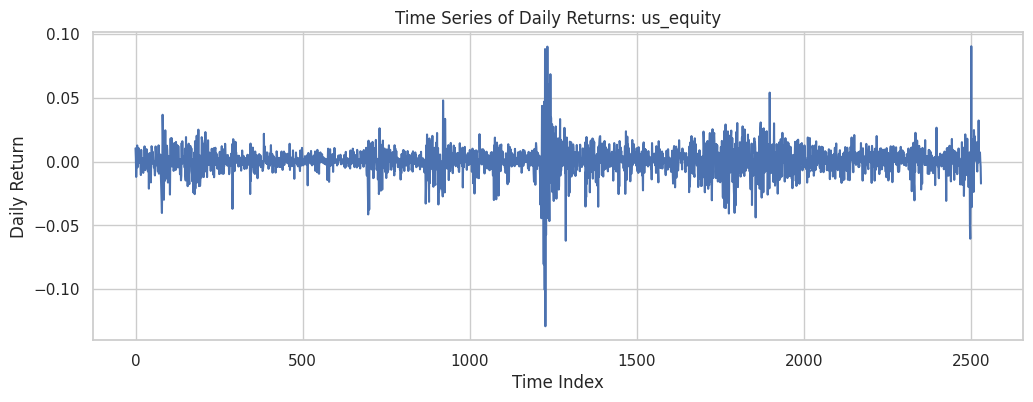

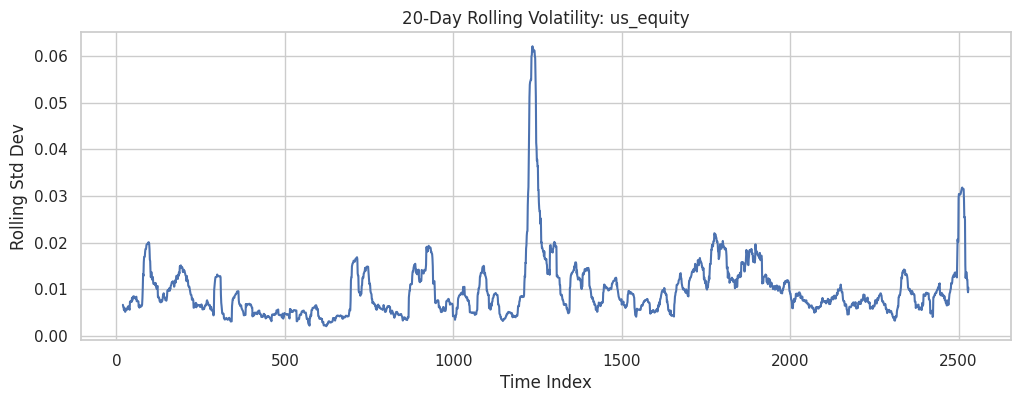


### INFLATION ###


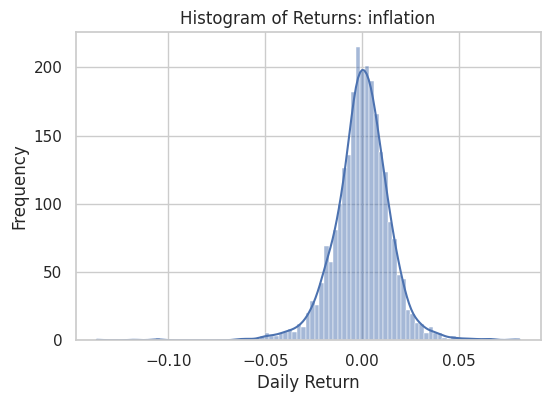

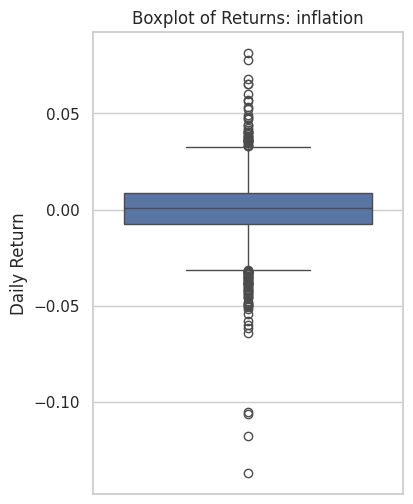

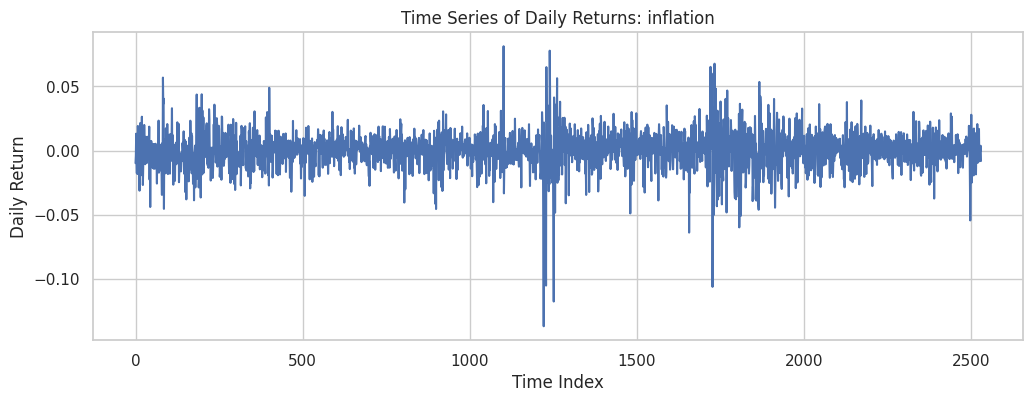

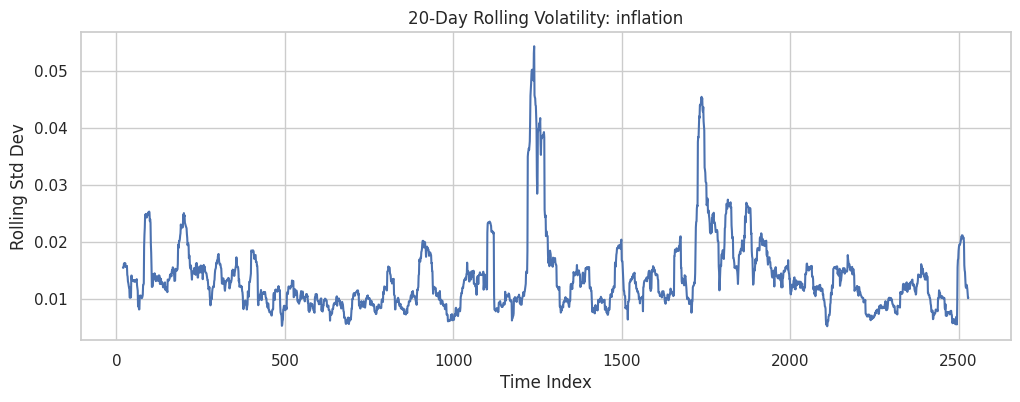


### BITCOIN ###


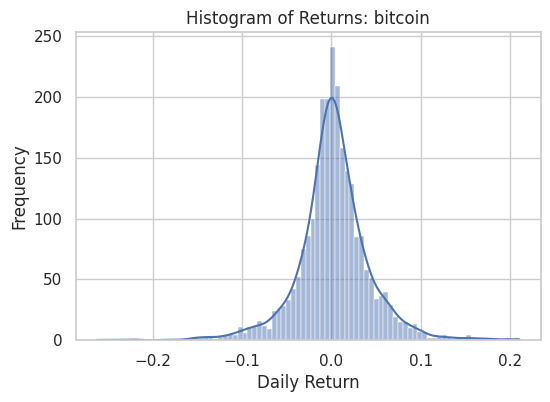

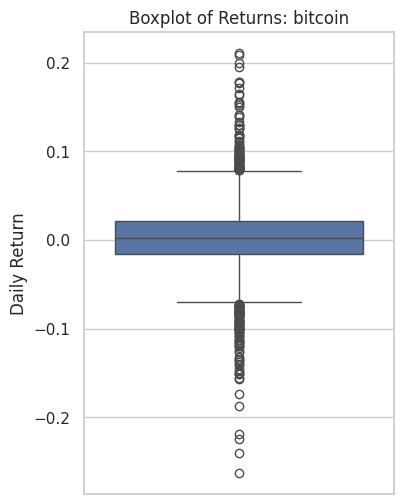

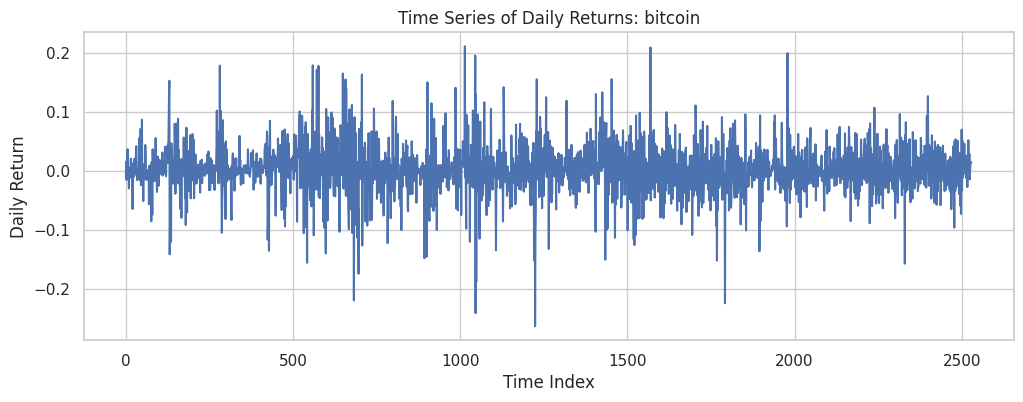

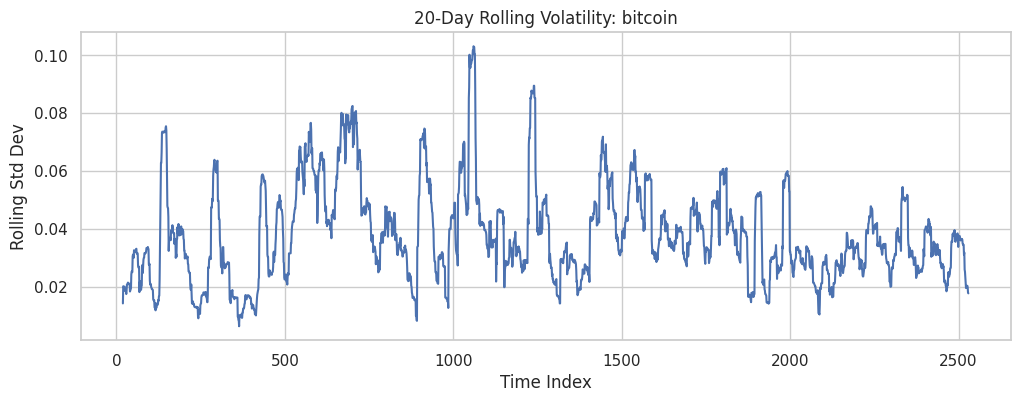


### EM_EQUITY ###


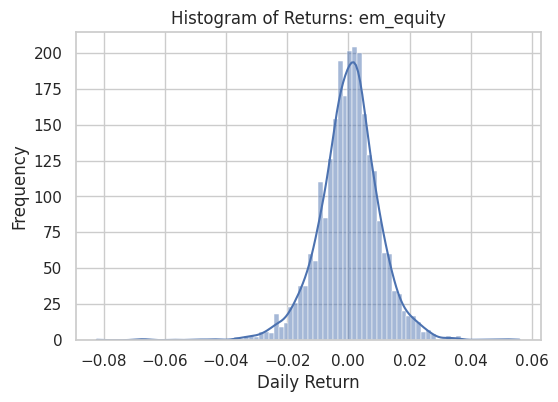

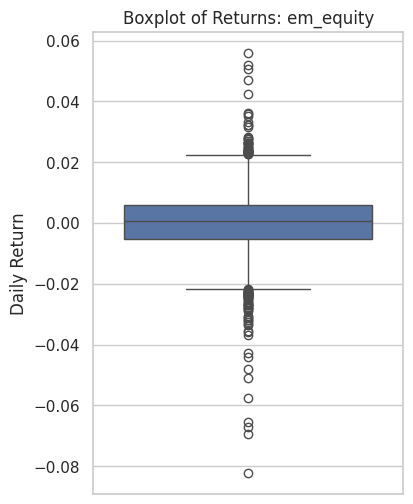

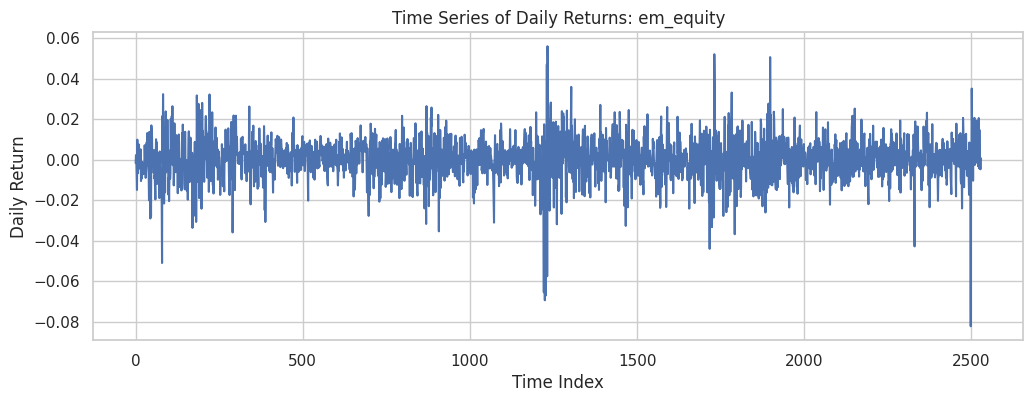

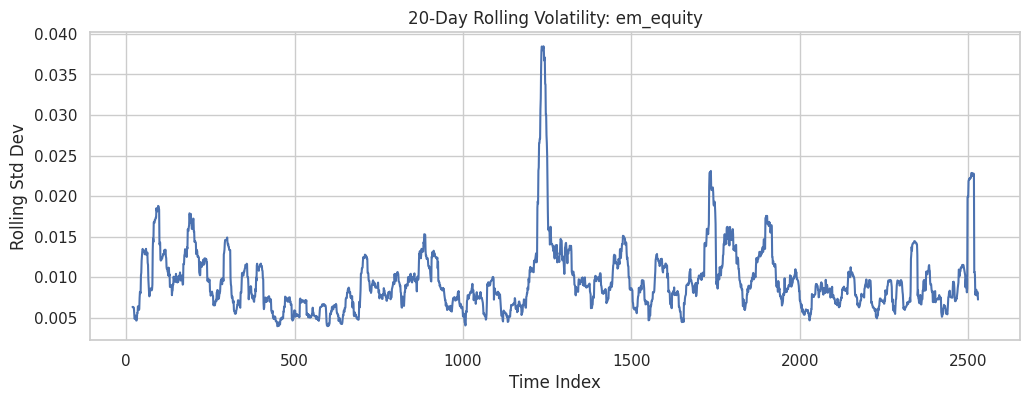

In [39]:
# EDA on Secondary Macro Assets

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

return_df = pd.read_csv("return_df.csv")
category_map_df = pd.read_csv("category_map.csv")

# secondary macro categories
secondary_macro_categories = ['us_dollar', 'us_equity', 'inflation', 'bitcoin', 'em_equity']
my_assets = [col for col in return_df.columns if col in secondary_macro_categories]
secondary_macro_returns = return_df[my_assets]

# plots
sns.set(style="whitegrid")

for asset in my_assets:
    print(f"\n### {asset.upper()} ###")

    # Histogram with KDE
    plt.figure(figsize=(6, 4))
    sns.histplot(secondary_macro_returns[asset], kde=True)
    plt.title(f"Histogram of Returns: {asset}")
    plt.xlabel("Daily Return")
    plt.ylabel("Frequency")
    plt.show()

    # Boxplot
    plt.figure(figsize=(4, 6))
    sns.boxplot(y=secondary_macro_returns[asset])
    plt.title(f"Boxplot of Returns: {asset}")
    plt.ylabel("Daily Return")
    plt.show()

    # Time series of returns
    plt.figure(figsize=(12, 4))
    plt.plot(secondary_macro_returns[asset])
    plt.title(f"Time Series of Daily Returns: {asset}")
    plt.xlabel("Time Index")
    plt.ylabel("Daily Return")
    plt.show()

    # Rolling 20-day volatility
    plt.figure(figsize=(12, 4))
    secondary_macro_returns[asset].rolling(window=20).std().plot()
    plt.title(f"20-Day Rolling Volatility: {asset}")
    plt.xlabel("Time Index")
    plt.ylabel("Rolling Std Dev")
    plt.show()


In [ ]:
### US Dollar
# The US Dollar has a tight symmetric return distribution with low volatility. 
# The boxplot shows very few outliers, and rolling 20-day volatility remains stable. 
# This aligns with its role as a defensive asset.

### US Equity
# US Equity returns show moderate volatility with occasional jumps. 
# Time series plots highlight event-driven fluctuations, while the volatility plot reveals spikes during COVID-19.

### Inflation
# Inflation-linked feature show mild right-skewed returns and moderate volatility.
# Occasional large movements suggests likely relation to macro news. Rolling volatility reflects sustained uncertainty periods.

### Bitcoin
# Bitcoin is the most volatile asset in the subgroup. 
# The distribution has extreme tails and the time series shows massive spikes and dips. Rolling volatility swings widely.

### EM Equity
# EM Equity returns are wider than developed markets. 
# Histograms and boxplots show frequent minor outliers. 
# Volatility cycles are visible likely mirroring global macro themes and EM-specific risks.

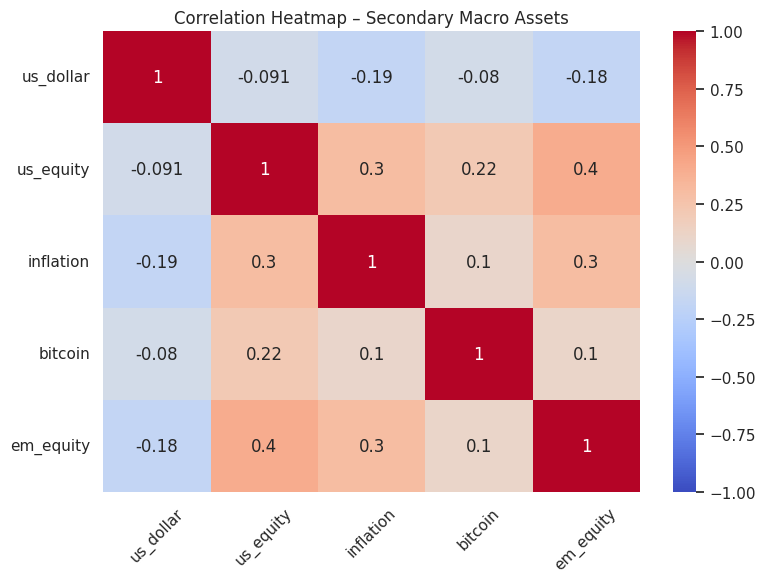

In [13]:
#  correlation matrix
corr_matrix = secondary_macro_returns.corr()

# heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap – Secondary Macro Assets")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


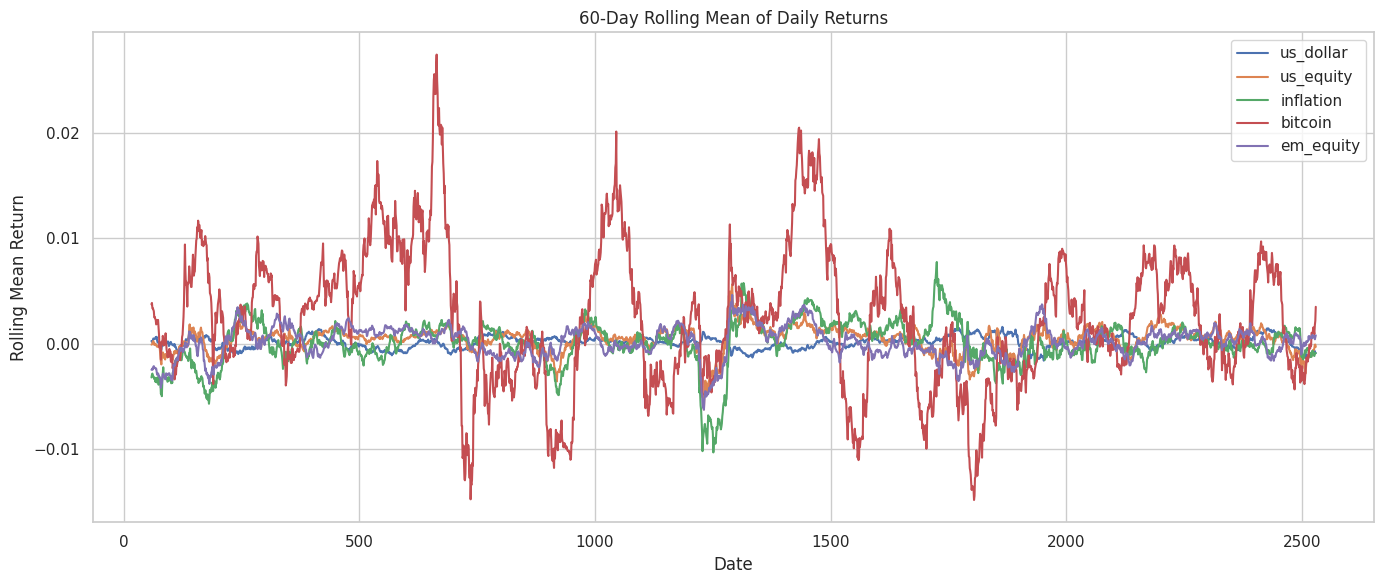

In [21]:
# Rolling Mean of Daily Returns (60d window)
selected_assets = ['us_dollar', 'us_equity', 'inflation', 'bitcoin', 'em_equity']
rolling_returns = return_df[selected_assets].rolling(window=60).mean()

plt.figure(figsize=(14, 6))
for col in selected_assets:
    plt.plot(rolling_returns[col], label=col)

plt.title("60-Day Rolling Mean of Daily Returns")
plt.xlabel("Date")
plt.ylabel("Rolling Mean Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
